# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename) # YOUR CODE HERE

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1. I chose the Census Income dataset (censusData.csv) which contains demographic, employment, and education information that was collected from the 1994 U.S. Census.
2. The label is income_binary column, which contains either of two values as <=50K or >50K. The binary classification model that I am creating will predict whether an individual's annual income is greater than 50,000 dollars (>50K) or less than or equal to 50,000 dollars (<=50K).
3. The features I plan to use for the model are age, education, education_num, workclass, occupation, marital-status, relationship, hours-per-week, capital-gain, capital-loss.
4. This problem matters because the AI prediction model can help EquiLend's nonprofit client company improve the efficiency and consistency of its loan and financial assistance eligibility process for its programs. Instead of having to manually review candidates for the financial education programs, the binary classification model can quickly estimate whether the applicant's income is above or below the $50,000 threshold so as to make choosing eligible applicants for the program easier. This would allow the nonprofit Community Development Financial Institution (CDFI) to make faster, more scalable, and data driven decisions while also helping them better serve underserved communities in the financial domain. 

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

In [3]:
# Value counts of label column distribution
df["income_binary"].value_counts()

<=50K    24720
>50K      7841
Name: income_binary, dtype: int64

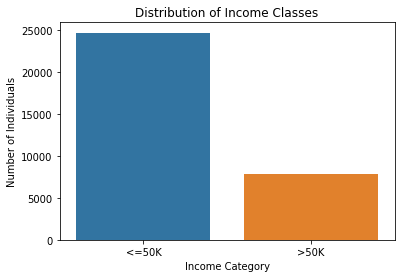

In [4]:
# Visualization
sns.countplot(data=df, x="income_binary")
plt.title("Distribution of Income Classes")
plt.xlabel("Income Category")
plt.ylabel("Number of Individuals")
plt.show()

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [5]:
# Data types of dataset columns
df.dtypes

age               float64
workclass          object
fnlwgt              int64
education          object
education-num       int64
marital-status     object
occupation         object
relationship       object
race               object
sex_selfID         object
capital-gain        int64
capital-loss        int64
hours-per-week    float64
native-country     object
income_binary      object
dtype: object

In [6]:
# Summary statistics for numerical columns
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32399.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32236.000000
mean,38.589216,1.897784e+05,10.080679,615.907773,87.303830,40.450428
std,13.647862,1.055500e+05,2.572720,2420.191974,402.960219,12.353748
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,14084.000000,4356.000000,99.000000


In [7]:
# Number of null values in each column
df.isnull().sum().sort_values(ascending=False)

occupation        1843
workclass         1836
native-country     583
hours-per-week     325
age                162
income_binary        0
capital-loss         0
capital-gain         0
sex_selfID           0
race                 0
relationship         0
marital-status       0
education-num        0
education            0
fnlwgt               0
dtype: int64

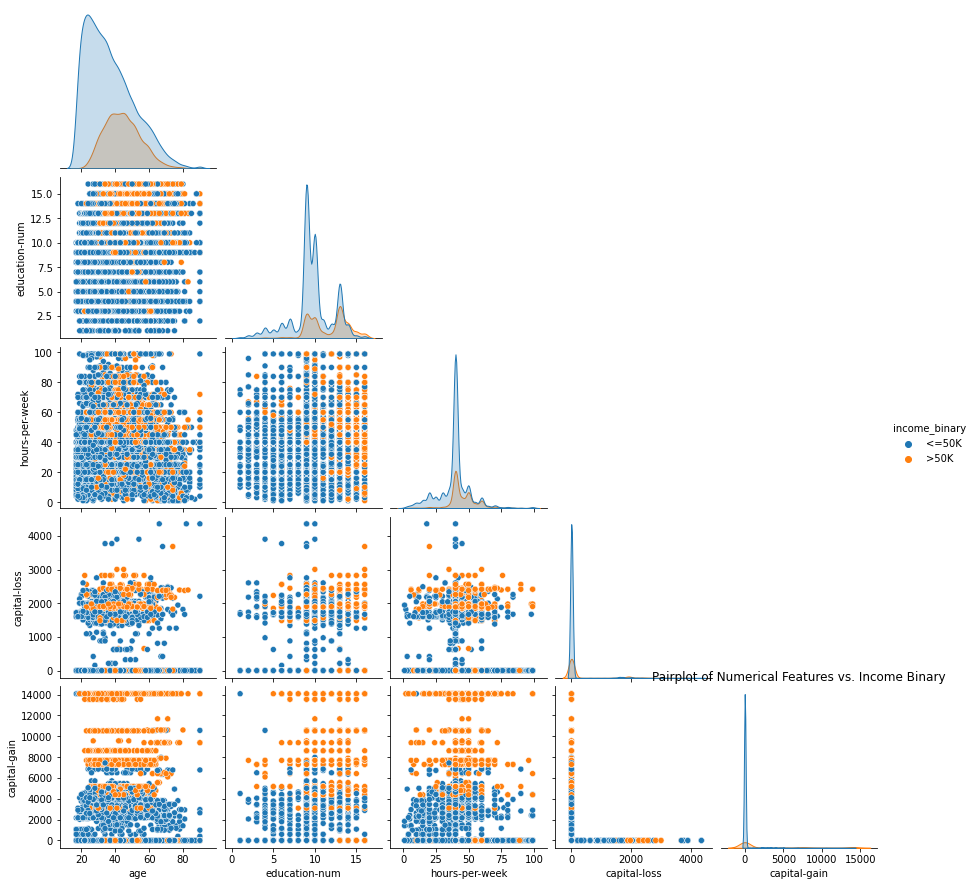

In [8]:
# PairPlot of Numerical Features

pairplot_features = ["age", "education-num", "hours-per-week", "capital-loss", "capital-gain"]

sns.pairplot(
    df[pairplot_features + ["income_binary"]],
    hue = "income_binary",
    corner = True,
    ) 

plt.title("Pairplot of Numerical Features vs. Income Binary")
plt.show()

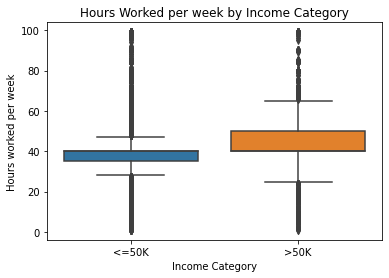

In [9]:
# Boxplot of Hours Per Week Feature and Income_Binary Label

sns.boxplot(x = "income_binary", y = "hours-per-week", data=df)

plt.title("Hours Worked per week by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Hours worked per week")

plt.show()

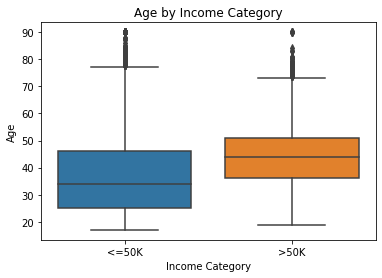

In [10]:
# Boxplot of Age Feature and Income_Binary Label

sns.boxplot(x = "income_binary", y = "age", data=df)

plt.title("Age by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Age")

plt.show()

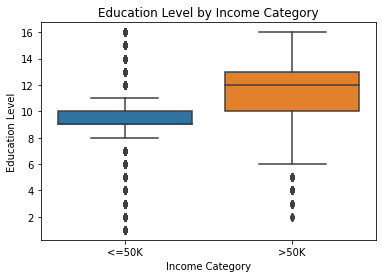

In [11]:
# Boxplot of Education-num Feature and Income_Binary Label

sns.boxplot(x = "income_binary", y = "education-num", data=df)

plt.title("Education Level by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Education Level")

plt.show()

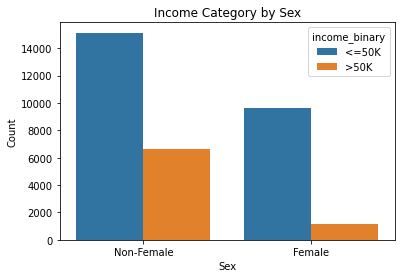

In [12]:
# Sex Demographic Information Plot

sns.countplot(x="sex_selfID", hue = "income_binary", data=df)

plt.title("Income Category by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")

plt.show()

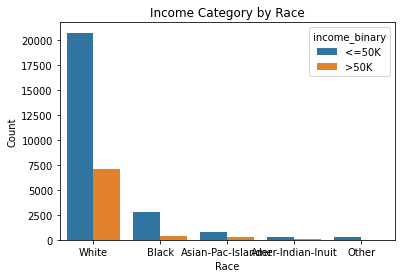

In [13]:
# Race Demographic Information Plot

sns.countplot(x="race", hue = "income_binary", data=df)

plt.title("Income Category by Race")
plt.xlabel("Race")
plt.ylabel("Count")

plt.show()

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

Discussion: 

The exploratory data analysis revealed important characteristics of the Census Income dataset that effect the data preparation process, feature selection, and model selection. 

As shown in the bar graph above, the label column income_binary has imbalance, with 24720 examples for the <=50K class (which is approximately 75%) and 7841 examples for the >50K class (which is approximately 25%). Since this class imbalance is present in the dataset, the accuracy metrics from model testing and evaluation may not provide an correct picture of the model's perforamce. This imbalance may cause the model to become biased towards predicting the majority class (<=50K) while being unable to accurately predict individuals with income >50K. To address this issue in model development, I will use multiple metrics to evaluate the model's performance, such as F1 score, instead of only relying on the model's accuracy. 

The data exploration identified that many of the columns in the dataframe are of an "object" datatype as categorical features and will need to be transformed to numerical format before training the model. These columns/features include workclass, education, martial-status, occupation, relationship, race, sex-selfID, and native country. To do this, I plan to use one-hot encoding to convert the categorical features into numerical representations for inputs in model training. The income_binary label column will also be converted to a numeric binary format.

The data exploration also identified missing/null values in several of the columns/features, including occupation(1843), workclass(1836), native-country(583), hours-per-week (325), age(162). Since missing values can introduce bias into the model training process, I will evaluate if the amount and location of the missing values effect the model in the data prepation phase and remove rows/examples with the missing information.

The pairplot analysis provides insight into the relationship between numerical features and the income_binary label. In the pairplot, features such as age, education-num, hours-per-week, capital-loss, and capital-gain show differences between individuals earning <=50K and >50K, suggesting that these features would provide useful information for making predictions. For example, individuals with higher education levels and greater capital gains appear to have higher income levels in the >50K category. 

The boxplots for hours-per-week, age, and education-num identified potential outliers, with some individuals having unusually higher/lower values outside of the typical range, such as extremely high work hours. These values may be standarized if they pose a problem.

The box plots for sex and race demographic information show differences between the different sex/race classess as well as between the income category. This is important to note because this uneven income distribution could highlight potential bias/fairness concerns that reflect inequalities that could effect the model's performance on minority groups. Therefore, in order to reduce the bias, I may not include the demographic columns as features in the models training process.

Overall, based on the exploratory data analysis, the data preparation process will include handling missing values, encoding categorical columns/features, evaluating potential outliers, and addressing class imbalance and demographic bias.


### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

Discussion: 

1. The Census Income dataset contains potential bias and ethical concerns that should be considered when developing the machine learning model. The Census dataset was collected from U.S. Census records in 1994, and therefore, reflects the demographic and employment patterns that existed at that time period that may not be reflective of the patterns today (in 2026). Since historical data can contain past social and economic inequalities, a model trained on this data may make predictions based on the inequalities it learns from the dataset. Specifically, the Census dataset contains sensitive demographic features such as sex and race that may act as proxies for socioeconomic status. For example, other features such as education level, occupation, and native country may also indirectly capture information about a person socioeconomic background or employment limitations. Therefore, training on these demographic features may cause the model to favor groups that have historically had access to higher paying job opportunities while disadvantaging those who have faced barriers in the employment sector.

2. The model incorrectly predicting an individual's income level could negatively affect people who rely on financial assistance programs, loans, or other services provided by the CDFI. For example, individuals who are incorrectly classified as earning above 50K dollars may not be selected for the financial aid programs, thereby making most at risk to the model's errors as they are unable to access programs intended to support low-income individuals like them. This would in turn limit their ability to receive financial resources, education, or assistance. Specifically, groups that have historically had a disadvantage in the employment sector, such as racial minorities, women, and individuals with lower education background, would be at risk if the model learns patterns from biased historical data since the CDFI's elgibility decisions for their financial programs would be based on the model predictions. On the other hand, if the model incorrectly classified individuals as earning below 50K dollars, this would lead to inaccurate elgibility assessment/decisions from CDFI and require additional manual review to ensure that only those who need the financial program that most are getting it. 

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [14]:
# Removing rows containing missing values
df.dropna(inplace=True)

# Check to make sure all null values were removed
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex_selfID        0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income_binary     0
dtype: int64

In [15]:
# Removes features that will not be used in training process before encoding
columns_drop = ["fnlwgt", "race", "sex_selfID", "native-country"]

df.drop(columns=columns_drop, inplace=True)

df.columns # Check the remaining feature columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'capital-gain', 'capital-loss',
       'hours-per-week', 'income_binary'],
      dtype='object')

In [16]:
# Convert label to binary values
df["income_binary"] = df["income_binary"].map({
    "<=50K" : 0,
    ">50K" : 1
})

df.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,capital-gain,capital-loss,hours-per-week,income_binary
0,39.0,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,2174,0,40.0,0
1,50.0,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,0,0,13.0,0
2,38.0,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,0,0,40.0,0
3,53.0,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,0,0,40.0,0
4,28.0,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,0,0,40.0,0


In [17]:
# One-Hot Encodes Categorical Features
cat_cols = df.select_dtypes(include="object").columns.tolist()

if "income_binary" in cat_cols:
    cat_cols.remove("income_binary")

df = pd.get_dummies(
    df,
    columns = cat_cols,
    drop_first = True
)

df.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,income_binary,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
0,39.0,13,2174,0,40.0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,50.0,13,0,0,13.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,38.0,9,0,0,40.0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,53.0,7,0,0,40.0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,28.0,13,0,0,40.0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,1


In [18]:
# Scale Features
features_col = df.columns.drop("income_binary")
scaler = StandardScaler()
df[features_col] = scaler.fit_transform(df[features_col])

### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

Discussion: 

Multiple data preparation steps were performed on the Census Income dataset based on findings from the exploratory data analysis.

In regard to the missing values in the Census dataset, rows that contained null values were removed from the dataset. This approach of removing rows with null values was chosen because the number of null observations was relatively small compared to the total size of the dataset. Additionally, I choose to remove incomplete records from the dataset because replacing the null values with estimates (such as median/mean) could introduce bias or mislead the true composition of the dataset. 

In regard to the features in the dataset, the demographic columns "race", "sex_selfID", and "native-country" were removed from the Census dataset because they could introduce a potential source of bias or unfairness if the model was trained on them. These features represent sensitive demographic information that could introdce bias concerns if the model was using that information for its predictions as the model may base its predictions based on historical inequalities/patterns that would disadvantage minority groups. Additionally, the "fnlwgt" feature was also removed because it represented the census sampling weight rather than a characterisitc of an individual that was sampled. Therefore, by removing these features, we would prevent the model from training on biased or irrelevant data, and instead focus on features that are better predictors of an individual's income level.

The categorical features/columns in the Census dataset, such as workclass, education, occuption, and relationship, were transformed to numerical format using one-hot-encoding. One-hot-encoding was used for this transformation because these features contained categorical information that did not have an inherent order. For example, the categories in the "education" column, such as Bachelors, HS-grad, 11th, represent different groups, but assigning them numerical values could incorrectly imply that one cateogry is mathematically greater than another. Therefore, one-hot-encoding was used to create separate binary columns for each category, where the value 1 indicated that the observation belonged to the category and a value of 0 meant that it did not. Additionally, the label "income_binary" was also converted from categorical values to binary format, with <=50K corresponding to 0 and >50K corresponding to 1. 

The features where also scaled/standarized using StandardScaler because the Logistic Regression model that I plan to use could be influenced by features with different numerical ranges. Scaling puts all numerical values on a similar range so that some features do not heavily influence the model because they have larger values.

The exploratory data analysis revealed class imbalance in the "income_binary" label column, with 75% of the dataset belonging to the <=50K class and 25% belonging to the >50K class. However, I did not alter the class distribution during data preparation because the dataset reflects true Census data from the United States and altering it could remove important information or introduce additional bias. Instead, I will address the class imbalance issue in the model training and evaluation phase by ensuring that the model's performance is evaluated through multiple metrics, such as F1 score as well as accuracy.

Overall, the dataset has been cleaned and preprocessed, with missing values handled, biased or irrelevant features removed, categorical variables encoded, features scaled, and class imbalanced addressed.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [19]:
# Create labeled examples from the dataset
y = df["income_binary"]
X = df.drop("income_binary", axis=1)

print("Number of examples:" + str(X.shape[0]))
print("Number of features:" + str(X.shape[1]))

Number of examples:29716
Number of features:50


In [20]:
# Create training and test sets out of the labeled examples 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state=1234, stratify=y)

print("Training Set", X_train.shape)
print("Testing Set", X_test.shape)

Training Set (19909, 50)
Testing Set (9807, 50)


In [21]:
# Train, test and evaluate your model

# Initialize Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=1234)

# Fit model to training data
log_reg_model.fit(X_train, y_train)

# Make predictions on test data
y_pred = log_reg_model.predict(X_test)

# Evaluate the model
log_reg_accuracy = accuracy_score(y_test, y_pred)

log_reg_f1 = f1_score(y_test, y_pred, average="binary")

print("Initial Logistic Regression Accuracy: ", log_reg_accuracy)
print("Initial Logistic Regression F1 Score: ", log_reg_f1)

Initial Logistic Regression Accuracy:  0.8454165392066891
Initial Logistic Regression F1 Score:  0.6591726618705036


In [22]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
param_grid = {
    "C" : [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "solver" : ["liblinear", "lbfgs"],
    "max_iter" : [500, 1000, 2000, 5000],
}

grid_search = GridSearchCV(
    estimator=log_reg_model,
    param_grid=param_grid,
    cv = 5,
    n_jobs = -1)

grid_search.fit(X_train, y_train)

print("Best Parameters: ")
print(grid_search.best_params_)

Best Parameters: 
{'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}


In [23]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
best_log_reg = grid_search.best_estimator_

final_pred = best_log_reg.predict(X_test)

final_accuracy = accuracy_score(y_test, final_pred)

final_f1 = f1_score(y_test, final_pred, average="binary")

print("Final Model Accuracy: ", final_accuracy)
print("Final Model F1 Score: ", final_f1)

Final Model Accuracy:  0.8460283470990109
Final Model F1 Score:  0.6606741573033709


In [24]:
# Interpret your model's outputs 

# Model Coefficients
coefficients = pd.DataFrame({
    "Feature" : X.columns,
    "Coefficient" : best_log_reg.coef_[0]
})

coefficients = coefficients.sort_values(
    by = "Coefficient", 
    ascending = False)

coefficients

,Feature,Coefficient
27,marital-status_Married-civ-spouse,0.880910
2,capital-gain,0.853412
1,education-num,0.527783
4,hours-per-week,0.373808
0,age,0.345727
34,occupation_Exec-managerial,0.298051
3,capital-loss,0.250969
40,occupation_Prof-specialty,0.180521
19,education_Bachelors,0.170658
22,education_Masters,0.141428


Text(0, 0.5, 'Feature')

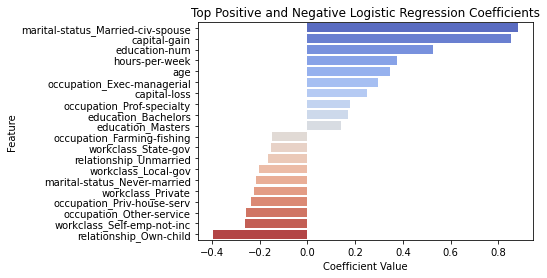

In [25]:
# Plot of top 10 positive and 10 negative model coefficients

top_positive = coefficients.head(10)
top_negative = coefficients.tail(10)

top_coefficients = pd.concat([top_positive, top_negative])

sns.barplot(
    data=top_coefficients,
    x="Coefficient",
    y="Feature",
    palette="coolwarm"
)

plt.title("Top Positive and Negative Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

Discussion: 

1. The model that I selected was Logistic Regression because the business problem is a binary classification task that predicts whether an individual's income is <=50 dollars or >50K dollars. A Logistic Regression model is well suited for this binary classification problem because it estimates the probability that an example belongs to one of two class, such as the <=50K and >50K classes. Since the Census Income dataset contained both categorical and numerical data, Logisitic Regression was an appropriate choice after applying one-hot-encoding to the categorical features and scaling numerical features. Additionally, Logisitc Regression is interpretable because it produces coefficients that quantify how much each feaature influences the likelihood of the positive class, therefore making it benefiscial for the nonprofit company as they would be able to understand why the model made a prediction based on the model coefficients. Therefore, since Logisitic Regression model performs efficiently on relatively large datasets, it is a appropriate baseline that we can use to compare with the neural network development in the second part of this capstone project.

2. The model selection process was performed using GridSearchCV with cross-validation to identify the optimal combination of hyperparameters for Logistic Regression. The grid search evaluated different values for the following hyperparameters: regularization strength (C), optimization solver, and maximum number of iteration. The best performing model used the following optimal hyperparameters: C=0.1, max_iter=500, solver=liblinear. Compared with the initial Logistic Regression model, the optimized model produced a small improvement in performance with the initial model having an accuracy of 84.54% and a F1-score of 0.659 and the optimized model achieving an accuracy of 84.60% and a F1-score of 0.661. Although the improvements in accuracy and F1-score were relatively small, they demonstrate that hyperparameter tuning does improve the model's ability to generalize to unseen data. Additionally, this also suggests that the initial Logistic Regression model was performing well on the Census dataset. 

3. A Logistic Regression model produces a coefficient for every feature in the model which indicates how much the feature influences the probability of the positive class, which is an individual earning an income of >50K dollars in this problem. A positive coefficient increases the likelihood of predicting the >50K income class, whereas a negative coefficient decreases that likelihood. In this Logistic Regression model, the largest positive coefficent was marital-status-Married-civ-spouse with a coefficient value of 0.881, suggesting the being married to and living with a spouse was the strongest positive predictor of earning more than 50K dollars. Some of the other strong positive predictors included capital-gain (0.853), education_num (0.528), and hours-per-week (0.374). On the other hand, the largest negative coefficient was relationship_Own-child with a coefficient value of -0.395, indicating that individuals who identified as a child were less likely to earn more than 50K dollars. Other negative predictors included occupation_Priv-house-serv (-0.237), occupation_Other-service (-0.258), and workclass_Self-emp-not-inc (-0.263). Overall, these coefficients are used by the model to estimate the probability that an applicant earns more than 50K dollars and, for the nonprofit, these coefficients can be used as a way to understand the model's predictions and use them more efficiently for determining eligibility to their financial programs.

4. Although sensitive demographic features like race, sex, and native country were removed from the dataset before training the model and the class imbalance issue was addressed through stratified sampling and using multiple evaluation metrics, there are still some areas where bias or fairness concerns remain. For example, some of the remaining variables, like relationship status, workclass, education level, occupation, and marital status may indirectly contain patterns for broader socioeconomic factors, thus causing the model to still learn historical patterns that reflect existing social and economic inequalities. In this case, an incorrect prediction could have a significant consequence for individuals seeking financial assistance. For example, an individual who is earning less than 50K that is predicted to earn more than 50K by the model would result in lower-income individuals being ineligible for the program, which are the groups that would most be affected. On the other hand, an individual who is earning more than 50K that is predicted by the model to earn less than 50K would result in financial resources to not be directed towards the low-income individuals who need it. While both are significant errors, the groups that would be most negatively affected by the error would be those who earn less than 50K but are predicted to earn more than 50K as they won't get access to those financial aid programs.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [26]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [27]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
nn_model.add(keras.layers.Input(shape=(n_features,)))

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.

nn_model.add(keras.layers.Dense(units=32, activation='relu'))
nn_model.add(keras.layers.Dense(units=16, activation='relu'))

# Discussion: I choose two hidden layers with 32 and 16 units respectively. 
# The two hidden layers provide enough complexity to learn nonlinear relationships
# in the Census Income dataset without creating an overly complex model.
# The 32 units was selected for the first hidden layer to allow the network
# to learn a variety of feature interactions from the Census data and the 16
# units were selected in the second hidden layer to gradually reduce the network
# complexity while continuing to learn the higher-level patterns. Lastly, the
# ReLU (Rectified Linear Unit) was chosen for the activation function because
# it trains efficiently and helps avoid the vanishing gradient problem.

# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
nn_model.add(keras.layers.Dense(units=1, activation = "sigmoid"))

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 32)                1632      
_________________________________________________________________
dense_1 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 17        
Total params: 2,177
Trainable params: 2,177
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [28]:
# Decision: What learning rate will you use? Add a comment explaining your decision.

sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

# Discussion: I selected the stochastic gradient descent (SGD) with a learning
# rate of 0.01. I chose 0.01 for the learning rate because it is a common 
# starting value that allows the model to efficiently learn while maintaining
# stable updates to the model's weights/parameters. In general, a larger learning
# rate may exceed the optimal solution, where a smaller learning rate may
# slow down the model training process.

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [29]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [30]:
nn_model.compile(
    optimizer = sgd_optimizer,
    loss = loss_fn,
    metrics = ["accuracy"]
)

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [31]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [32]:
# Decision: How many epochs? Add a comment.

t0 = time.time() # start time

num_epochs = 100

history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=num_epochs,
    validation_split=0.2,
    callbacks = [ProgBarLoggerNEpochs(num_epochs, every_n=10)]
)

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

# Discussion: I chose to train the model with 100 epochs because this number
# provides the model with sufficient opportunities to learn the patterns in 
# the training data without memorizing the training data. In general, too few
# epochs would lead to underfitting because the model doesn't have enough
# exposure to the data to learn meaningful patterns. On the other hand, too
# many epochs would lead to overfitting because the model would memorize the 
# patterns in the training data and, thus, not generalize well to new unseen
# data. Therefore, 100 epoch is a good middle ground to prevent both underfitting
# and overfitting.

Epoch 1/100
498/498 [==============================] - 5s 4ms/step - loss: 0.5372 - accuracy: 0.7249 - val_loss: 0.4052 - val_accuracy: 0.8184
Epoch 2/100
498/498 [==============================] - 2s 4ms/step - loss: 0.3659 - accuracy: 0.8356 - val_loss: 0.3550 - val_accuracy: 0.8370
Epoch 3/100
498/498 [==============================] - 1s 3ms/step - loss: 0.3421 - accuracy: 0.8423 - val_loss: 0.3414 - val_accuracy: 0.8385
Epoch 4/100
498/498 [==============================] - 1s 3ms/step - loss: 0.3341 - accuracy: 0.8454 - val_loss: 0.3369 - val_accuracy: 0.8383
Epoch 5/100
498/498 [==============================] - 1s 3ms/step - loss: 0.3296 - accuracy: 0.8458 - val_loss: 0.3332 - val_accuracy: 0.8418
Epoch 6/100
498/498 [==============================] - 1s 3ms/step - loss: 0.3263 - accuracy: 0.8473 - val_loss: 0.3315 - val_accuracy: 0.8423
Epoch 7/100
498/498 [==============================] - 1s 3ms/step - loss: 0.3238 - accuracy: 0.8478 - val_loss: 0.3300 - val_accuracy: 0.8430

Epoch 55/100
498/498 [==============================] - 1s 2ms/step - loss: 0.2929 - accuracy: 0.8619 - val_loss: 0.3208 - val_accuracy: 0.8488
Epoch 56/100
498/498 [==============================] - 1s 2ms/step - loss: 0.2924 - accuracy: 0.8617 - val_loss: 0.3216 - val_accuracy: 0.8501
Epoch 57/100
498/498 [==============================] - 1s 3ms/step - loss: 0.2923 - accuracy: 0.8620 - val_loss: 0.3216 - val_accuracy: 0.8508
Epoch 58/100
498/498 [==============================] - 1s 2ms/step - loss: 0.2920 - accuracy: 0.8639 - val_loss: 0.3214 - val_accuracy: 0.8516
Epoch 59/100
498/498 [==============================] - 1s 2ms/step - loss: 0.2916 - accuracy: 0.8640 - val_loss: 0.3227 - val_accuracy: 0.8491
Epoch 60/100
498/498 [==============================] - 1s 2ms/step - loss: 0.2914 - accuracy: 0.8627 - val_loss: 0.3213 - val_accuracy: 0.8533
Epoch [60/ 100], Loss: 0.2914, Accuracy: 0.8627, Val_loss: 0.3213, Val_accuracy: 0.8533
Epoch 61/100
498/498 [==========================

### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



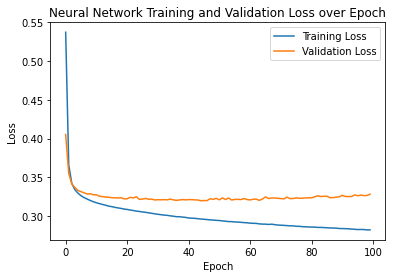

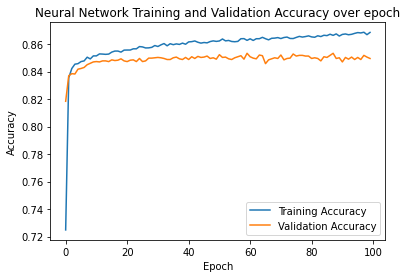

In [33]:
# Plot training loss and validation loss over epochs
plt.plot(
    history.history["loss"],
    label = "Training Loss"
)
plt.plot(
    history.history["val_loss"],
    label = "Validation Loss"
)
plt.title("Neural Network Training and Validation Loss over Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot training accuracy and validation accuracy over epochs
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.title("Neural Network Training and Validation Accuracy over epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [34]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

y_pred_nn_prob = nn_model.predict(X_test_scaled)

y_pred_nn = (y_pred_nn_prob >= 0.5).astype(int)

In [35]:
# Compute accuracy and F1 score for the neural network and print the results
nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn, average="binary")

print("Neural Network Accuracy:", nn_accuracy)
print("Neural Network F1 Score:", nn_f1)

Neural Network Accuracy: 0.8469460589374936
Neural Network F1 Score: 0.6629238715472716


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

Discussion:

1 - For the neural network architecture, I decided to create a simple feedforward neural network design to balance the model's complexity, trainig time, and ability to effectively learn patterns from the Census Income dataset. Since this is a binary classification problem to predict whether an individual's income is more than 50K dollars, the neural network was designed for binary output. 

The neural network consisted of an input layer, two hidden layers, and a output layer. The input layer was designed with the number of neurons equal to the number of features in the dataset. The model used two hidden layers, with the first containing 32 units and the second containing 16 units. I chose two hidden layers because the Census Income dataset contains complex relationships between demographic, employment, and educational characteristics that may not be captured in a simple linear model. Therefore, by adding two hidden layers, the neural network is able to learn more complex interactions between features. The first hidden layer contains 32 units because it is reponsbile for identifying a board range of patterns from the input and the second layer contains 16 units so as to gradually reduce the information learned by the neural network and identify the most important high level patterns for making predictions. Therefore, the two hidden layers with 32 and 16 units respectively provides enough complexity to learn meaingful relationships in the data without the risk of overfitting. 

For the hidden layers, I used the ReLU (Rectified Linear Unit) activiation function because it is commonly used in neural networks due to its ability to efficiently learn nonlinear relationship while preventing vanishing gradient point issues. Since the income prediction model depends on interactions between multiple features, the ReLU allows the neural network to capture patterns that may not be visible in a linear model.

The output layer had one neuron with a sigmoid activation function since this is a binary classification task with two possible outcomes: <=50K and >50K. Thus, the sigmoid function converts the model outputs to a probability between 0 and 1.

For optimization, I selected the stochastic gradient descent (SGD) with a learning rate of 0.01. The learning rate influences how large of a step the model takes when updating weights during training. Therefore, I chose a value of 0.01 because it provides a balance between training speed and stability. For example, a large learning rate would miss the optimal solution whereas a small learning rate would have a slow/inefficeint training process.

For epoch, I chose 100 epochs because it provides enough training iterations for the model to learning the patterns in the Census dataset without overfitting. For instance, too few epochs would lead to underfitting because the model doesn't have enough exposure to the data to learn meaningful patterns whereas too many epochs would lead to overfitting because the model would memorize the # patterns in the training data and, thus, not generalize well to new unseen data. Therefore, 100 epoch is a good middle ground.

2 - Based on the training curves, the neural network does show signs of overfitting. In the plots, the training loss  decreases from approximately 0.55 to 0.25 over the 100 epochs, which indicates that the model is continously learning new patterns from the training data. The validation loss shows a similar trend and gradually decreases from 0.40 to 0.34. This difference in loss trends suggest that the model is becoming more specialized to the training data, which is hurting its ability to generalize to unseen data in the validation set. This pattern is also seen in the accuracy curves. In the plots, the training accuracy increases from 72% to 86.5%, while the validation accuracy increases from around 82%-85%. This suggests that while the model is learning additional patterns from the training data, it is not improving the model's performance as much on new unseen data. This also shows that after a certain epoch number, more training has unnoticable improvments and may increase the risk of overfitting. 

There is no sign of underfitting sign the training accuracy is relatively high and the training loss continues to decrease. Underfitting would be present if both training and validation performance remained poor over the epoch number. 

3 - The neural network achieved an accuracy of 84.74% and a F1 score of 0.671 on the test set. This shows that the model was able to correctly classify the income level of most of the individuals in the Census Income dataset while also being able to identify the minority income class (>50K). The F1 score is important to note because the original dataset contained class imbalance with about 75% of examples belonging to the <=50K class and only 25% belonging to the >50K class. Therefore, the high F1 score indicates that the model achieved a better balance between precision and recall when prediciting high-income individuals.

Additionally, the test results did not surprise me given the training curves as the curves showed some signs of overfitting as the training loss continued to decrease while validation loss increased and training accuracy improved while validation accuracy remained relatively consistnet. Based on this, I would expect the model to perform better on the training data then new unseen data, but nevertheless the neural network still generalized well with a high 84.74% accuracy.

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [36]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
# results = pd.DataFrame({
#     'Metric': ['Accuracy', 'F1 Score'],
#     'KNN Model': [knn_accuracy, knn_f1],
#     'Neural Network': [nn_accuracy, nn_f1]
# })
# print(results.to_string(index=False))
#

results = pd.DataFrame({
    "Metric": ["Accuracy", "F1 Score"],
    "Logistic Regression": [final_accuracy, final_f1],
    "Neural Network": [nn_accuracy, nn_f1]
})

print(results.to_string(index=False))


   Metric  Logistic Regression  Neural Network
 Accuracy             0.846028        0.846946
 F1 Score             0.660674        0.662924


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1. The Logistic Regression and Neural Network models both performed well on the Census Income classification problem, with similar overall accuaracy and F1 scores but slightly stronger performance from the Neural Network. This is represented in the table above with the optimized Logistic Regression model achieving an accuracy of 84.60% and an F1 score of 66.07%, while the Neural Network achieved an accuracy of 84.74% and an F1 score of 67.16%. Therefore, the Neural Network improved both accuracy and F1 score evaluation metrics as represented by an approximately 0.13% increase in accuracy and approximately 1.10% increase in F1 score. Specifically, the higher F1 score for the neural network showed that it was slightly better at balancing precision and recall when predicting individuals in the higher-income category. Additioanlly, neither model showed a meaningful decrease in performance as they were both able to learn important patterns from the Census Income dataset, as shown through the high accuracy and high F1 scores for both models.

2. Although the neural network achieved a slighly better performance in terms of accuracy and F1 scores, the added complexity was not justified for this classification problem. As detailed in part 1, the neural network improved the F1 score by approximately 1.10% and the accuracy by 0.13%, which is only a slight increase given the complexity of the neural network architecture. Unlike the Logistic Regression model, the neural network required additional achitecture design decisions such as number of layers, number of units, activation functions, learning rate, and training epoch as well as more computational resources. In fact, the neural network model could also be more difficult to interpret than traditional models. In comparison, the Logistic Regression model was simplier and produced nearly equivalent predictive performance for the binary classification problem while also being more interpretable for the nonprofit company. For instance, the coefficients from the Logistic Regression model clearly showed which feature were associated with higher or lower predicted income level, which is useful if the nonprofit wanted to understand how the model based its decisions. Since this problem as deals with financial eligibility decisions that can significantly affect low-income individuals, having omre interpretable model and output would be more valuable for the nonprofit client. Therefore, even though the neural network had slightly better performance, the complexity it added to the classification problem was not justified in this case.

3. If I were presenting this project to EquiLend and its CDFI client, I would recommend deploying the Logistic Regression model for the income classification task. While the neural network achieved slightly better accuracy and F1 scores, the difference in performance between the two models was not significant enough to outweigh the benefits of the Logistic Regression model. Since the CDFI will use this model to help make decisions related to eligibility of its financial programs for underserved communities, being transparent and accountable for their decisions are most important. In that way, the Logistic Regression model would allow the stakeholders and CDFI to better understand why the model made its decisions because the model coefficients show how different features influence the probability of an individual earning more than 50K dollars. This interpretability aspect of the Logistic Regression model makes it easier for the nonprofit to identify potential bias, explain its decisions to stakeholders, and maintain oversight over the model's prediction process. In addition to these benefits, the Logistic Regression model would also require less computational power, trains faster, and is easier to update and monitor in comparison to the neural network architecture. Additionally, when considering the cost of the model's error, since the performance between the two models is almost the same, the risk of error would also be similar. Therefore, it would be advised that the model be used as a support tool alongside human review to ensure that errors don't negatively affect low-income individuals who require the support of the nonprofit financial programs. Therefore, since the Logistic Regression model is more interpretable to clients through its model coefficients, it would be better in helping to identify potential sources of error, such as unintential demographic or socioeconomic bias.

4. If I had more time, I would focus on improving both the model's performance and bias/fairness in evaluation. First, I would explore additional methods for addressing the class imbalance issue that was identified during exploratory data analysis. Although the current high F1 scores of both models suggest lessened bias in the model training and evaluation process, other methods I could explore to further reduce this bias include applying class weights during neural network training or oversampling the minority class. Secondly, I would like to experiment with additional neural network architectures, such as adding more hidden layers or changing the learning rate and epoch values. In the training curves above, the neural network showed some signs of overfitting, so techniques to reduce overfitting like lessening the number of neurons or shortening the training time could improve the model's ability to generalize to new unseen data. Thirdly, I would like to perform further analysis on the demographic features that I removed from the dataset in the initial data processing steps, such as sex, race, and native country. I would want to investigate whether including these features in the model training process would improve or worsen the model performance. Overall, through these approaches, I want to determine ways to improve the model's performance in identifying meaingful patterns in data while reducing bias and maintaining fairness.   

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1. I used ChatGPT in this capstone project as a supplemental learning tool to better understand the machine learning material. For example, during the initial data preprocessing stages, I used ChatGPT to brainstorm ideas for different preprocessing tools I could used, such as techniques to address the class imbalance issue that was apparent in the Census Income dataset. Additionally, later in the capstone, I also used ChatGPT to understand the advantages and disadvantages of changing the neural network parameters, such as increasing or decreasing the learning rate, epoch number, number of hidden layers, or various activation functions. This helped me understand how the choices I made regarding the neural network parameters would influence the model training process as well as the potential for overfitting to the training data. In addition, I also used ChatGPT as a reference to reinforce concepts that I learned in this course but wanted clarification on. For example, I used AI to verify my understanding of the one-hot-encoding technique I used in the data preprocessing stage and also referred back to the previous labs to verify the AI's answers. On the other hand, I did not use AI to generate code as I wanted to understand the decisions I made and use the knowledge and tools I used in this capstone, as often AI suggests libraries that are outside of the scope of a course. In this way, I used AI primarily as a learning tool to improve my understanding of concepts we learning in this course or for understanding the pros and cons of the modeling decision I made in the capstone. 

2. The most challenging part of the capstone was the data preparation process as I had difficultly determining which preprocessing steps were most appropriate for the Census Income dataset. The dataset contained both numerical and categorical variables, missing values, potential outliers, bias from demographic information, and class imbalance issues. Therefore, it was hard determining which charactertistics of the dataset should be kept the same and which should be corrected. For example, one of the AI prompts that worked well in understanding which potential directions I could take the data preprocessing was "I am processing a Census Income dataset for a binary classification task that predicts an individual's income level as either <=50K or >50K. The dataset contains missing values, class imbalance, and demographic features like race and sex. What are some data preprocessing steps that I should consider and what are the risks and benefits associated with each one?" This prompt helped me think through and consider multiple approaches to preprocessing the data instead of relying on the first approach that came to mind. Therefore, ChatGPT helped me consider multiple viewpoints and take the most appropriate course of action regarding data preprocessing.

3. I verified the outputs I recieved from ChatGPT by referring back to the course materials (especially previous labs/assigments) as well as official documentation I found online. For example, when ChatGPT referred to a concept or technique I was unfamiliar with, such as the Logistic Regression parameters for tunning, I researched the topic using reliable sources online to verify the information I was given by the AI. For example, some of the reliable sources I used for verification purposes was official documentation from Scikit-learn and Tensorflow/Keras website. Additionally, I also used AI to understand errors I was given when running the code cells, and verifyed the information by ensuring that the code ran correctly after any alternations I made. For example, I would check whether the dataset's feature columns were encoded properly after I reran the code for the one-hot-encoding when I received an error on it. Overall, this helped me ensure that the information I was receiving from AI was factual and not a hallucination. 

4. Next time, I would incorporate AI earlier in my planning process and use it more systematicaly as a tool for organizing my thoughts and ideas. Throughout the project, I asked ChatGPT very vague questions when I encountered a challenge, such as if I didn't understand how to use a library or what the different layers in neural network did. Instead, if I were to do this capstone again, I would use a more effective approach of using AI from the beginning to help me create a structured plan for the machine learning lifecycle, including model selection and evaluation criteria. I would also use AI to help me understand potential sources of bias that I could have introduced in the training process and how to best address fairness concerns. Overall, I would continue using AI as a learning resrouce, but also ask it more focused and target questions that would help me compare different ML approaches to a problem. 